# Imports

In [1]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import r2_score
from scipy.stats import spearmanr, kruskal
from sklearn.linear_model import LinearRegression


def merged_lesions_csv(dir_path: str | Path) -> dict[str, pd.DataFrame]:
    """
    Scans a directory for spine lesion radiomics CSV files, groups them by their
    imaging type, and merges them into centralized DataFrames per image modality.
    """
    base_dir = Path(dir_path)

    # 1. Use pathlib's rglob for deep scanning of the target CSV pattern
    all_csv_files = base_dir.rglob("*spine_lesions*.csv")

    # Registry to group file paths by their filename: {csv_name: [Path, Path, ...]}
    csv_groups = defaultdict(list)
    result_dict = {}

    # 2. Group discovered CSV files by their exact filename
    for file_path in all_csv_files:
        csv_groups[file_path.name].append(file_path)

    # 3. Process each group and merge individual patient tables
    for csv_name, file_paths in csv_groups.items():
        loaded_dfs = []

        for file_path in file_paths:
            # Read the target CSV file
            df = pd.read_csv(file_path)

            # Extract the patient folder name (parent directory of the file)
            patient_name = file_path.parent.name

            # Insert the patient identifier safely as the very first column
            df.insert(0, "patient", patient_name)
            loaded_dfs.append(df)

        if not loaded_dfs:
            continue

        # Clean the key name by removing the standard suffix to keep it short
        clean_key_name = csv_name.replace("_radiomics_spine_lesions_features.csv", "")

        # Concatenate all patient rows into one large master DataFrame for this modality
        master_df = pd.concat(loaded_dfs, ignore_index=True)
        result_dict[clean_key_name] = master_df

    return result_dict

# Correlation between clinical and radiomic

In [3]:
# 1. Load clinical dataset and identify numerical biomarkers
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_clinical_features = clinical_df.select_dtypes(include=['number']).columns

# 2. Fetch all processed radiomics CSV files from the target directory
all_image_datasets = merged_lesions_csv(r"E:\DATA_Myelomy")

# ==================================================================
# CROSS-CORRELATION ANALYSIS: Clinical vs Radiomic Features
# ==================================================================

for dataset_name, radiomic_df in all_image_datasets.items():
    print(f"\n==================================================")
    print(f"PROCESSING DATASET: {dataset_name}")
    print(f"==================================================")

    # Merge clinical data with radiomics features on patient identifiers
    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')

    if merged_df.empty:
        print(f"Skipping {dataset_name}: No matching patients found between clinical and image data.")
        continue

    # Identify numerical radiomics features from the source image dataframe
    numeric_image_features = radiomic_df.select_dtypes(include=['number']).columns

    # Iterate through each numerical clinical column to find correlation targets
    for clinical_col in numeric_clinical_features:

        # Safety check: ensure the column exists in the merged dataset
        if clinical_col not in merged_df.columns:
            continue

        significant_correlations = {}

        # Test each radiomics feature against the current clinical biomarker
        for radiomic_col in numeric_image_features:
            # Isolate the pair and drop missing values to avoid calculation bias
            data_subset = merged_df[[radiomic_col, clinical_col]].dropna()

            # Spearman correlation requires a minimum of 2 complete observations
            if len(data_subset) > 1:
                correlation_coeff, p_value = spearmanr(
                    data_subset[radiomic_col],
                    data_subset[clinical_col],
                    nan_policy='omit'
                )

                # Store the feature only if the correlation is statistically significant
                if p_value < 0.05:
                    significant_correlations[radiomic_col] = {
                        'Correlation (rho)': correlation_coeff,
                        'p-value': p_value
                    }

        # Display findings for the current clinical column
        print(f"\nResults for Clinical Biomarker: '{clinical_col}'")

        if significant_correlations:
            # Convert results dictionary to DataFrame and sort by strength of correlation
            results_df = pd.DataFrame(significant_correlations).T
            results_df = results_df.sort_values(by='Correlation (rho)', ascending=False)

            print("  Top 3 Positive Correlations:")
            print(results_df.head(3))
            print("\n  Top 3 Negative Correlations:")
            print(results_df.tail(3))
        else:
            print("  No statistically significant correlations found.")

        print("-" * 50)


PROCESSING DATASET: BMD

Results for Clinical Biomarker: 'Serum M-protein quantity (g/l)'
  Top 3 Positive Correlations:
                                                 Correlation (rho)   p-value
gradient_glrlm_GrayLevelNonUniformityNormalized           0.358793  0.004876
gradient_glrlm_LowGrayLevelRunEmphasis                    0.319706  0.012772
gradient_firstorder_Kurtosis                              0.299008  0.020300

  Top 3 Negative Correlations:
                                              Correlation (rho)   p-value
gradient_glrlm_GrayLevelVariance                      -0.333171  0.009289
gradient_glrlm_ShortRunHighGrayLevelEmphasis          -0.350281  0.006075
gradient_glrlm_HighGrayLevelRunEmphasis               -0.351978  0.005817
--------------------------------------------------

Results for Clinical Biomarker: 'Serum kappa FLC quantity (mg/l'
  Top 3 Positive Correlations:
                   Correlation (rho)  p-value
gradient_glcm_MCC           0.288916  0.02276

 

# Scatter plot visualization

Targeting Image Type: monoe_40kev
Targeting Pair:       'original_glcm_Idm' vs 'Beta2 microglobulin (mg/l)'
------------------------------------------------------------
--- Statistical Summary (monoe_40kev) ---
Spearman rho:               0.5053
p-value:                    9.50227e-06
Significant (p < 0.05):     True
Goodness of Fit (R-squared): 0.0600 (6.00% of variance explained)
----------------------------------------


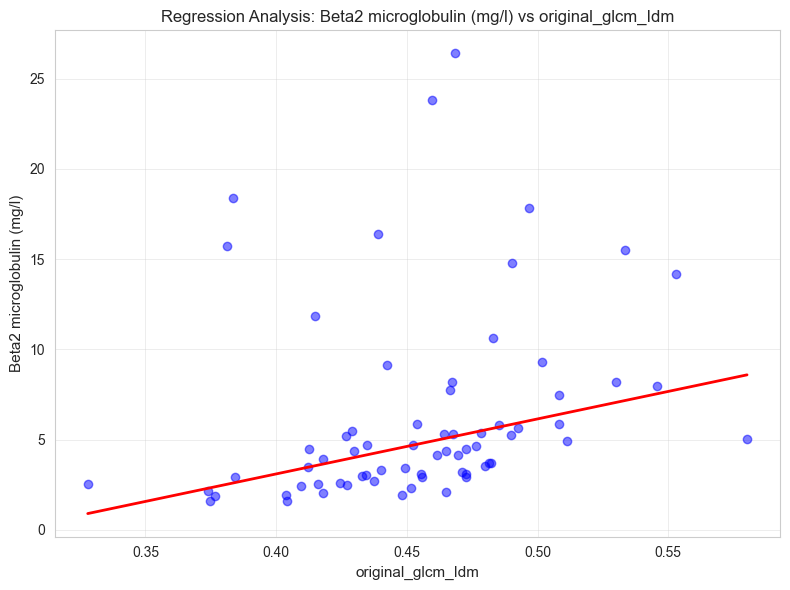

In [8]:
# ==================================================================
# USER CONFIGURATION: Select your targets here
# ==================================================================
target_image_type = "monoe_40kev"                   # e.g., "CaSupp_25", "konv", "monoe_40kev"
target_clinical_col = "Beta2 microglobulin (mg/l)"   # Exact name of the clinical column
target_radiomic_col = "original_glcm_Idm" # Exact name of the radiomic column

print(f"Targeting Image Type: {target_image_type}")
print(f"Targeting Pair:       '{target_radiomic_col}' vs '{target_clinical_col}'")
print("-" * 60)

# ==================================================================
# DATA PROCESSING & VISUALIZATION
# ==================================================================

# Check if the requested image type exists in your loaded datasets
if target_image_type in all_image_datasets:
    radiomic_df = all_image_datasets[target_image_type]

    # Merge image features with clinical data based on patient IDs
    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')

    # Validation 1: Check if columns actually exist in the merged dataset
    if target_radiomic_col not in merged_df.columns:
        print(f"Error: Radiomic feature '{target_radiomic_col}' not found in the dataset.")
    elif target_clinical_col not in merged_df.columns:
        print(f"Error: Clinical column '{target_clinical_col}' not found in the dataset.")
    else:
        # Isolate the pair and drop rows with missing values for statistical accuracy
        subset = merged_df[[target_radiomic_col, target_clinical_col]].dropna()

        if len(subset) > 1:
            # Calculate Spearman correlation coefficient and p-value
            correlation_coeff, p_value = spearmanr(
                subset[target_radiomic_col],
                subset[target_clinical_col],
                nan_policy='omit'
            )

            # Calculate Goodness of Fit (R-squared) for the baseline trend
            X_fit = subset[[target_radiomic_col]].values
            y_fit = subset[target_clinical_col].values

            lin_model = LinearRegression()
            lin_model.fit(X_fit, y_fit)
            y_pred = lin_model.predict(X_fit)
            r2 = r2_score(y_fit, y_pred)

            print(f"--- Statistical Summary ({target_image_type}) ---")
            print(f"Spearman rho:               {correlation_coeff:.4f}")
            print(f"p-value:                    {p_value:.5e}")
            print(f"Significant (p < 0.05):     {p_value < 0.05}")
            print(f"Goodness of Fit (R-squared): {r2:.4f} ({r2 * 100:.2f}% of variance explained)")
            print("-" * 40)

            # Generate the plot
            sns.set_style("whitegrid")
            plt.figure(figsize=(8, 6))

            # Render regression plot with robust estimator and no confidence interval shadow
            sns.regplot(
                data=subset,  # Using subset to ensure clean data mapping
                x=target_radiomic_col,
                y=target_clinical_col,
                ci=None,
                robust=True,
                scatter_kws={'alpha': 0.5, 'color': 'blue'},
                line_kws={'color': 'red', 'linewidth': 2}
            )

            # Format the title to show the image type, correlation, and significance
            plt.title(f"Regression Analysis: {target_clinical_col} vs {target_radiomic_col}", fontsize=12)
            plt.xlabel(target_radiomic_col, fontsize=11)
            plt.ylabel(target_clinical_col, fontsize=11)

            plt.tight_layout()
            plt.show()
        else:
            print("Error: Not enough data points available after dropping NaNs to compute correlation.")
else:
    print(f"Error: Image type '{target_image_type}' was not found in 'all_csvs' keys.")

# Kruskal-Wallis test between clinical and radiomic

In [4]:
# 1. Load clinical dataset and define categorical risk/staging factors
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
categorical_clinical_features = ["ISS classification", "M-protein type", "Light chain type"]

# 2. Fetch all processed radiomics CSV files from the target directory
all_image_datasets = merged_lesions_csv(r"E:\DATA_Myelomy")

# ==================================================================
# STATISTICAL ANALYSIS: Kruskal-Wallis Test (Categorical vs Radiomic)
# ==================================================================

for dataset_name, radiomic_df in all_image_datasets.items():
    print(f"\n==================================================")
    print(f"PROCESSING DATASET: {dataset_name}")
    print(f"==================================================")

    # Merge clinical data with radiomics features on patient identifiers
    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')

    if merged_df.empty:
        print(f"Skipping {dataset_name}: No matching patients found.")
        continue

    # Identify numerical radiomics features from the source image dataframe
    numeric_image_features = radiomic_df.select_dtypes(include=['number']).columns

    # Iterate through each categorical clinical biomarker
    for clinical_col in categorical_clinical_features:

        # Safety check: ensure the column exists in the merged dataset
        if clinical_col not in merged_df.columns:
            continue

        significant_features = {}

        # Test each radiomics feature across the categories of the clinical column
        for radiomic_col in numeric_image_features:
            # Drop missing values across BOTH columns simultaneously to prevent sample mismatch
            data_subset = merged_df[[radiomic_col, clinical_col]].dropna()

            # Group the radiomic values dynamically using the cleaned data subset
            groups = [
                group_data[radiomic_col].values
                for group_name, group_data in data_subset.groupby(clinical_col)
            ]

            # Kruskal-Wallis requires at least 2 distinct groups with data to perform a comparison
            if len(groups) > 1 and all(len(g) > 0 for g in groups):
                stat, p_value = kruskal(*groups)

                # Store the feature only if the variance across groups is statistically significant
                if p_value < 0.05:
                    significant_features[radiomic_col] = {
                        'H-statistic': stat,
                        'p-value': p_value
                    }

        # Display findings for the current clinical category
        print(f"\nResults for Clinical Categorical Feature: '{clinical_col}'")

        if significant_features:
            # Convert results dictionary to DataFrame and sort by the strength of the H-statistic
            results_df = pd.DataFrame(significant_features).T
            results_df = results_df.sort_values(by='H-statistic', ascending=False)

            print("  Top 3 Most Differentiating Radiomic Features (Highest H-stat):")
            print(results_df.head(3))
        else:
            print("  No statistically significant differences found across groups.")

        print("-" * 50)


PROCESSING DATASET: BMD

Results for Clinical Categorical Feature: 'ISS classification'
  Top 3 Most Differentiating Radiomic Features (Highest H-stat):
                                                 H-statistic   p-value
original_firstorder_Kurtosis                       17.551540  0.000154
original_firstorder_InterquartileRange             15.972294  0.000340
original_firstorder_RobustMeanAbsoluteDeviation    13.753247  0.001032
--------------------------------------------------

Results for Clinical Categorical Feature: 'M-protein type'
  Top 3 Most Differentiating Radiomic Features (Highest H-stat):
                                             H-statistic   p-value
gradient_glrlm_ShortRunLowGrayLevelEmphasis     8.630025  0.013366
gradient_firstorder_Kurtosis                    6.585165  0.037158
--------------------------------------------------

Results for Clinical Categorical Feature: 'Light chain type'
  Top 3 Most Differentiating Radiomic Features (Highest H-stat):
       

# Boxplot visualization

Targeting Image Type: monoe_40kev
Targeting Pair:       'gradient_firstorder_10Percentile' vs 'ISS classification'
------------------------------------------------------------
--- Kruskal-Wallis Test Summary (monoe_40kev) ---
H-statistic: 18.6314
p-value:     0.00009000
Significant: True



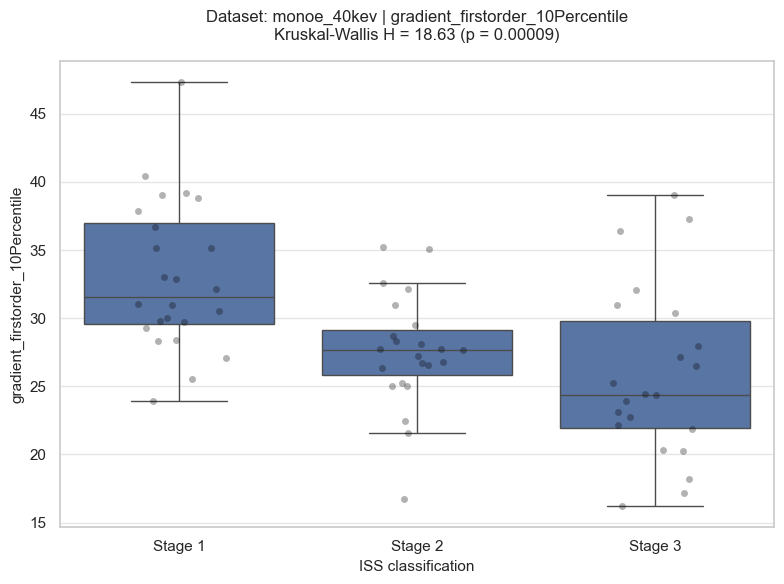

In [7]:
# 1. Load the clinical dataset
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
all_image_datasets = merged_lesions_csv(r"E:\DATA_Myelomy")

# ==================================================================
# USER CONFIGURATION: Select your targets here
# ==================================================================
target_image_type = "monoe_40kev"                             # e.g., "konv", "CaSupp_25", "monoe_40kev"
target_clinical_col = "ISS classification"              # e.g., "ISS classification", "M-protein type"
target_radiomic_col = "gradient_firstorder_10Percentile" # Exact name of the radiomic feature

print(f"Targeting Image Type: {target_image_type}")
print(f"Targeting Pair:       '{target_radiomic_col}' vs '{target_clinical_col}'")
print("-" * 60)

# ==================================================================
# DATA PROCESSING, STATISTICAL TESTING & VISUALIZATION
# ==================================================================

# Check if the requested image type exists in your loaded datasets
if target_image_type in all_image_datasets:
    radiomic_df = all_image_datasets[target_image_type]

    # Merge image features with clinical data based on patient IDs
    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')

    # Validation: Check if columns actually exist in the merged dataset
    if target_radiomic_col not in merged_df.columns:
        print(f"Error: Radiomic feature '{target_radiomic_col}' not found in the dataset.")
    elif target_clinical_col not in merged_df.columns:
        print(f"Error: Clinical column '{target_clinical_col}' not found in the dataset.")
    else:
        # Isolate the pair and drop missing values safely for accurate grouping
        data_subset = merged_df[[target_radiomic_col, target_clinical_col]].dropna()

        # Group the radiomic values dynamically using the cleaned data subset
        groups = [
            group_data[target_radiomic_col].values
            for group_name, group_data in data_subset.groupby(target_clinical_col)
        ]

        # Kruskal-Wallis requires at least 2 distinct groups with data
        if len(groups) > 1 and all(len(g) > 0 for g in groups):
            h_stat, p_value = kruskal(*groups)

            # Print text summary to console
            print(f"--- Kruskal-Wallis Test Summary ({target_image_type}) ---")
            print(f"H-statistic: {h_stat:.4f}")
            print(f"p-value:     {p_value:.8f}")
            print(f"Significant: {p_value < 0.05}\n")

            # Generate the Boxplot
            sns.set_style("whitegrid")
            plt.figure(figsize=(8, 6))

            # Plot boxplot without showing outliers (showfliers=False) for a cleaner look
            sns.boxplot(
                data=data_subset,
                x=target_clinical_col,
                y=target_radiomic_col,
                showfliers=False
            )

            # Add an optional stripplot over the boxplot to see raw data point distribution
            sns.stripplot(
                data=data_subset,
                x=target_clinical_col,
                y=target_radiomic_col,
                color="black",
                alpha=0.3,
                jitter=0.2
            )

            # Format the title to show statistical results dynamically
            plt.title(
                f"Dataset: {target_image_type} | {target_radiomic_col}\n"
                f"Kruskal-Wallis H = {h_stat:.2f} (p = {p_value:.5f})",
                fontsize=12,
                pad=15
            )
            plt.xlabel(target_clinical_col, fontsize=11)
            plt.ylabel(target_radiomic_col, fontsize=11)

            plt.tight_layout()
            plt.show()
        else:
            print("Error: Not enough unique groups or data points available to perform Kruskal-Wallis test.")
else:
    print(f"Error: Image type '{target_image_type}' was not found in the dataset registry.")